In [1]:
#!pip install torch

     -------------------------------------- 162.6/162.6 MB 6.1 MB/s eta 0:00:00


In [2]:
import torch


In [3]:
a = torch.tensor([[1,2], [3,4], [5,6]])

In [4]:
a

tensor([[1, 2],
        [3, 4],
        [5, 6]])

In [5]:
b = torch.tensor([[1,2,3,4],[5,6,7,8]])

In [6]:
b

tensor([[1, 2, 3, 4],
        [5, 6, 7, 8]])

In [7]:
a @ b

tensor([[11, 14, 17, 20],
        [23, 30, 37, 44],
        [35, 46, 57, 68]])

In [9]:
import torch.nn as nn

In [23]:
import numpy as np
import seaborn as sns

In [434]:
size = 500
np.random.seed(100)
noise = np.random.uniform(-0.1, 0.1, size)
X_train_raw = np.random.uniform(-np.pi, np.pi, size)
y_train_raw = np.sin(X_train_raw) + noise
#y_train_raw = np.sin(X_train_raw)

<AxesSubplot:>

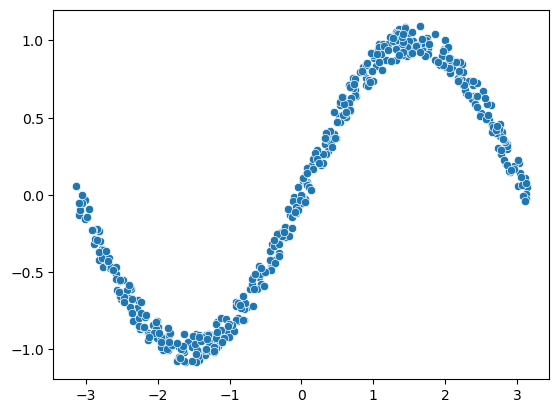

In [435]:
sns.scatterplot(x=X_train_raw, y=y_train_raw)

In [436]:
X_test_raw = np.random.uniform(-np.pi, np.pi, size//10)
noise = np.random.uniform(-0.1, 0.1, size//10)
y_test_raw = np.sin(X_test_raw) + noise
#y_test_raw = np.sin(X_test_raw)

<AxesSubplot:>

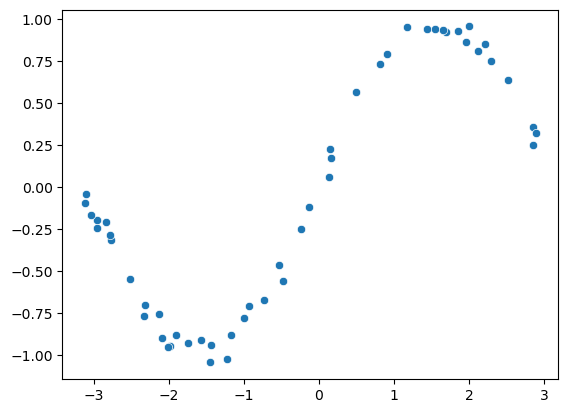

In [437]:
sns.scatterplot(x=X_test_raw, y=y_test_raw)

In [459]:
class myFNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.w1 = nn.Linear(1, 64)
        self.relu1 = nn.ReLU()
        self.w2 = nn.Linear(64, 64)
        self.relu2 = nn.ReLU()
        self.w3 = nn.Linear(64, 1)
        
        
    def forward(self, x):
        out = self.w1(x)
        out = self.relu1(out)
        out = self.w2(out)
        out = self.relu2(out)
        return self.w3(out)

In [460]:
model = myFNN()

In [461]:
loss = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [462]:
X_train = torch.tensor(X_train_raw[:, np.newaxis], dtype=torch.float32)
y_train = torch.tensor(y_train_raw[:, np.newaxis], dtype=torch.float32)

In [463]:
epoch = 1000
for _ in range(epoch):
    pred = model(X_train)
    err = loss(pred, y_train)
    if _ % (epoch // 10) == 0:
        print(err)

    optimizer.zero_grad()
    err.backward()
    optimizer.step()

tensor(0.5449, grad_fn=<MseLossBackward0>)
tensor(0.0995, grad_fn=<MseLossBackward0>)
tensor(0.0602, grad_fn=<MseLossBackward0>)
tensor(0.0338, grad_fn=<MseLossBackward0>)
tensor(0.0205, grad_fn=<MseLossBackward0>)
tensor(0.0146, grad_fn=<MseLossBackward0>)
tensor(0.0117, grad_fn=<MseLossBackward0>)
tensor(0.0098, grad_fn=<MseLossBackward0>)
tensor(0.0086, grad_fn=<MseLossBackward0>)
tensor(0.0077, grad_fn=<MseLossBackward0>)


In [464]:
X_test = torch.tensor(X_test_raw[:, np.newaxis], dtype=torch.float32)
y_test = torch.tensor(y_test_raw[:, np.newaxis], dtype=torch.float32)

In [465]:
with torch.no_grad():
    pred = model(X_test)
    error = loss(pred, y_test)
    print(error)

tensor(0.0084)


In [466]:
x = np.linspace(-np.pi, np.pi, 200)
y = np.sin(x)

<AxesSubplot:>

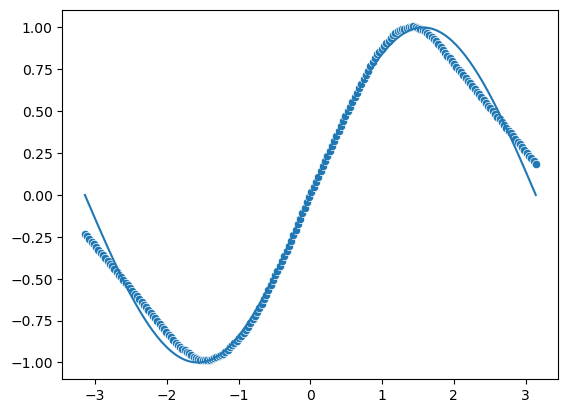

In [467]:
with torch.no_grad():
    X_for_plot = np.linspace(-np.pi, np.pi, 200)
    y_for_plot = model(torch.linspace(-np.pi, np.pi, 200).unsqueeze(1)).squeeze().detach().numpy()

sns.scatterplot(x=X_for_plot, y=y_for_plot)
sns.lineplot(x=x, y=y, )

In [11]:
import pandas as pd
from datasets import Dataset
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer

In [380]:
df = pd.read_csv('uniq_data.csv')

df = df.rename(columns={
            'STAGE': 'stage_id',
            'STRANGE': 'strange_id', 
            'GROUP': 'group_id',
            'EMOTION': 'emotion_id',
            'TRIGGER': 'trigger_id'
            }, 
         )
train_df, val_df = train_test_split(df, test_size=0.2)


In [381]:
df

,TEXT,stage_id,strange_id,group_id,emotion_id,trigger_id
0,"Слушай, я не хочу опять начинать, но ты снова ...",Предконфликтная,Низкая,Гнев,Раздражение,Быт
1,"Да замолчи ты уже, ради бога, ты слышишь тольк...",Пик,Высокая,Гнев,Злость,Личность
2,"Я видела твой телефон, когда пришло уведомлени...",Инцидент,Средняя,Страх,Напряжение/Нервозность,Ревность
3,"Прости, что я так сорвалась вчера, я действите...",Разрешение,Средняя,Социальные,Раскаяние,Внимание
4,"Опять твоя мама звонит в семь утра, чтобы расс...",Эскалация,Средняя,Гнев,Неодобрение,Родня
...,...,...,...,...,...,...
1655,Ты пообещал сходить со мной в парк и опять зас...,Инцидент,Средняя,Грусть,Обида,Внимание
1656,"Пошел вон, я видела твою переписку с «просто з...",Пик,Высокая,Гнев,Злость,Ревность
1657,"Я сегодня поняла, что была неоправданно строга...",Разрешение,Низкая,Социальные,Осознание,Быт
1658,"Твои бесконечные поучения, как мне общаться с ...",Эскалация,Средняя,Гнев,Раздражение,Родня


In [498]:
ids2labels = {key: df[key].unique() for key in df.keys() if key != "TEXT"}
labels2ids = {key: {label: i for i, label in enumerate(df[key].unique())} for key in df.keys() if key != "TEXT"}
ids2labels

{'stage_id': array(['Предконфликтная', 'Пик', 'Инцидент', 'Разрешение', 'Эскалация'],
       dtype=object),
 'strange_id': array(['Низкая', 'Высокая', 'Средняя'], dtype=object),
 'group_id': array(['Гнев', 'Страх', 'Социальные', 'Нейтральные', 'Позитив', 'Грусть'],
       dtype=object),
 'emotion_id': array(['Раздражение', 'Злость', 'Напряжение/Нервозность', 'Раскаяние',
        'Неодобрение', 'Нейтральность', 'Облегчение', 'Горе/Грусть',
        'Признательность/Радость', 'Страх', 'Эмпатия', 'Обида',
        'Осознание', 'Разочарование', 'Удивление', 'Оптимизм',
        'Желание/Мотивация', 'Любовь', 'Одобрение', 'Забота'], dtype=object),
 'trigger_id': array(['Быт', 'Личность', 'Ревность', 'Внимание', 'Родня', 'Контроль',
        'Деньги', 'Дети', 'Секс', 'Друзья'], dtype=object)}

In [500]:
labels2ids

{'stage_id': {'Предконфликтная': 0,
  'Пик': 1,
  'Инцидент': 2,
  'Разрешение': 3,
  'Эскалация': 4},
 'strange_id': {'Низкая': 0, 'Высокая': 1, 'Средняя': 2},
 'group_id': {'Гнев': 0,
  'Страх': 1,
  'Социальные': 2,
  'Нейтральные': 3,
  'Позитив': 4,
  'Грусть': 5},
 'emotion_id': {'Раздражение': 0,
  'Злость': 1,
  'Напряжение/Нервозность': 2,
  'Раскаяние': 3,
  'Неодобрение': 4,
  'Нейтральность': 5,
  'Облегчение': 6,
  'Горе/Грусть': 7,
  'Признательность/Радость': 8,
  'Страх': 9,
  'Эмпатия': 10,
  'Обида': 11,
  'Осознание': 12,
  'Разочарование': 13,
  'Удивление': 14,
  'Оптимизм': 15,
  'Желание/Мотивация': 16,
  'Любовь': 17,
  'Одобрение': 18,
  'Забота': 19},
 'trigger_id': {'Быт': 0,
  'Личность': 1,
  'Ревность': 2,
  'Внимание': 3,
  'Родня': 4,
  'Контроль': 5,
  'Деньги': 6,
  'Дети': 7,
  'Секс': 8,
  'Друзья': 9}}

In [384]:
for item in train_dataset:
    for key in item:
        if key != "TEXT" and key != "__index_level_0__":
            
    break

IndentationError: expected an indented block after 'if' statement on line 3 (864537952.py, line 5)

In [390]:
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)

tokenizer = AutoTokenizer.from_pretrained('cointegrated/rubert-tiny2')

def tokenize(examples):
    tokenized = tokenizer(examples['TEXT'], truncation=True, padding=True)
    for key in examples:
        if key != "TEXT" and key != "__index_level_0__":
            tokenized[key] = [labels2ids[key][label] for label in examples[key]]
            
    return tokenized

train_dataset_tokenized = train_dataset.map(tokenize, batched=True, remove_columns=['__index_level_0__', "TEXT"])
val_dataset_tokenized = val_dataset.map(tokenize, batched=True, remove_columns=['__index_level_0__', "TEXT"])


Map:   0%|          | 0/1328 [00:00<?, ? examples/s]

Map:   0%|          | 0/332 [00:00<?, ? examples/s]

In [392]:
train_dataset_tokenized

Dataset({
    features: ['stage_id', 'strange_id', 'group_id', 'emotion_id', 'trigger_id', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 1328
})

In [9]:
!conda list | findstr transformers


sentence-transformers     5.1.0                    pypi_0    pypi
transformers              4.57.0.dev0              pypi_0    pypi


In [20]:
import torch
import torch.nn as nn
from transformers import AutoModel
from safetensors.torch import load_file
from transformers import AutoTokenizer

class MultiTaskRuBERT(nn.Module):
    def __init__(self, num_stages=5, num_stranges=3, num_groups=6, num_emotions=20, num_triggers=10):
        super().__init__()
        self.bert = AutoModel.from_pretrained('cointegrated/rubert-tiny2')
        self.hidden_size = self.bert.config.hidden_size  # 312

        self.stage_head = nn.Linear(self.hidden_size, num_stages)
        self.strange_head = nn.Linear(self.hidden_size, num_stranges)
        self.group_head = nn.Linear(self.hidden_size, num_groups)
        self.emotion_head = nn.Linear(self.hidden_size, num_emotions)
        self.trigger_head = nn.Linear(self.hidden_size, num_triggers)

        state_dict = load_file("my_final_model/model.safetensors")
        self.load_state_dict(state_dict)
        self.eval()

        self.tokenizer = AutoTokenizer.from_pretrained("my_final_model")

        self.task_order = ['stage_id', 'strange_id', 'group_id', 'emotion_id', 'trigger_id']
        self.ids2labels = {'stage_id': ['Предконфликтная', 'Пик', 'Инцидент', 'Разрешение', 'Эскалация'],
                           'strange_id': ['Низкая', 'Высокая', 'Средняя'],
                           'group_id': ['Гнев', 'Страх', 'Социальные', 'Нейтральные', 'Позитив', 'Грусть'],
                           'emotion_id': ['Раздражение', 'Злость', 'Напряжение/Нервозность', 'Раскаяние',
                                          'Неодобрение', 'Нейтральность', 'Облегчение', 'Горе/Грусть',
                                          'Признательность/Радость', 'Страх', 'Эмпатия', 'Обида',
                                          'Осознание', 'Разочарование', 'Удивление', 'Оптимизм',
                                          'Желание/Мотивация', 'Любовь', 'Одобрение', 'Забота'],
                           'trigger_id': ['Быт', 'Личность', 'Ревность', 'Внимание', 'Родня', 'Контроль',
                                          'Деньги', 'Дети', 'Секс', 'Друзья']
                           }
        self.labels2ids = {'stage_id': {'Предконфликтная': 0, 'Пик': 1, 'Инцидент': 2, 'Разрешение': 3, 'Эскалация': 4},
                           'strange_id': {'Низкая': 0, 'Высокая': 1, 'Средняя': 2},
                           'group_id': {'Гнев': 0,'Страх': 1,'Социальные': 2,'Нейтральные': 3,'Позитив': 4,'Грусть': 5},
                           'emotion_id': {'Раздражение': 0,'Злость': 1,'Напряжение/Нервозность': 2,'Раскаяние': 3,'Неодобрение': 4,
                                          'Нейтральность': 5,'Облегчение': 6,'Горе/Грусть': 7,'Признательность/Радость': 8,
                                          'Страх': 9,'Эмпатия': 10,'Обида': 11,'Осознание': 12,'Разочарование': 13,'Удивление': 14,
                                          'Оптимизм': 15,'Желание/Мотивация': 16,'Любовь': 17,'Одобрение': 18,'Забота': 19},
                           'trigger_id': {'Быт': 0,'Личность': 1,'Ревность': 2,'Внимание': 3,'Родня': 4,'Контроль': 5,'Деньги': 6,
                                          'Дети': 7,'Секс': 8,'Друзья': 9}}

    def forward(self, input_ids, attention_mask, token_type_ids, stage_id=None, strange_id=None,
                group_id=None, emotion_id=None, trigger_id=None, **kwargs):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)
        cls = outputs.pooler_output

        stage_logits = self.stage_head(cls)
        strange_logits = self.strange_head(cls)
        group_logits = self.group_head(cls)
        emotion_logits = self.emotion_head(cls)
        trigger_logits = self.trigger_head(cls)

        loss = None
        if stage_id is not None and strange_id is not None and group_id is not None and emotion_id is not None and trigger_id is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = (loss_fct(stage_logits, stage_id) +
                    loss_fct(strange_logits, strange_id) + 
                    loss_fct(group_logits, group_id) + 
                    2 * loss_fct(emotion_logits, emotion_id) +
                    1.5 * loss_fct(trigger_logits, trigger_id)) / 5

        return {
            'loss': loss,
            'logits': (stage_logits, strange_logits, group_logits, emotion_logits, trigger_logits)
        }

    def predict_samples(self, inputs: list[str], top_k=1):
        samples = self.tokenizer(inputs, padding=True, truncation=True)
        logits = self.forward(**{key: torch.tensor(val) for key, val in samples.items()})["logits"]

        out = {}
        for i, task in enumerate(self.task_order):
            val, idxes = logits[i].topk(top_k, dim=-1)
            out[task] = [[self.ids2labels[task][idx] for idx in row] for row in idxes]
        
        return out


In [456]:
model = MultiTaskRuBERT()

In [432]:
class MultiTaskDataCollator(DataCollatorWithPadding):
    def __call__(self, features):
        batch = super().__call__(features)
        
        # Для forward (чтобы считался loss)
        ids = ['stage_id', 'strange_id', 'group_id', 'emotion_id', 'trigger_id']
        for name in ids:
            batch[name] = torch.tensor([f[name] for f in features], dtype=torch.long)
        
        # Для compute_metrics (чтобы попало в label_ids)
        # Trainer ищет именно ключ "labels"
        batch['labels'] = torch.stack([batch[name] for name in ids], dim=1)
        
        return batch

In [402]:
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

In [404]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred.predictions, eval_pred.label_ids
    
    task_names = ['stage', 'strange', 'group', 'emotion', 'trigger']
    results = {}
    all_f1s = []

    for i, name in enumerate(task_names):
        preds = np.argmax(logits[i], axis=-1)
        label = labels[:, i]
        
        # Считаем Macro F1 для каждой задачи
        f1 = f1_score(label, preds, average='macro')
        
        results[f"{name}_f1"] = f1
        all_f1s.append(f1)

    # Среднее значение F1 по всем задачам - лучший ориентир
    results["mean_f1"] = np.mean(all_f1s)
    
    return results

In [406]:
from transformers import DataCollatorWithPadding
from transformers import TrainingArguments, Trainer

In [444]:
args = TrainingArguments(    
    output_dir="test_test_model",
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=10,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="mean_f1", # совпадает с ключом в compute_metrics
    label_names=["labels"] # Указываем явно!
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_dataset_tokenized,
    eval_dataset=val_dataset_tokenized,
    compute_metrics=compute_metrics,
    tokenizer=tokenizer,
    data_collator=MultiTaskDataCollator(tokenizer=tokenizer),
)


C:\Users\vaveyko\AppData\Local\Temp\ipykernel_1116\555160973.py:15: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [452]:
# with 2x emotion and 1.5x trigger
trainer.train()

D:\programs\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Stage F1,Strange F1,Group F1,Emotion F1,Trigger F1,Mean F1
1,No log,0.721970,0.845462,0.899360,0.867809,0.465348,0.562075,0.728011
2,0.692000,0.670175,0.871322,0.897425,0.883763,0.489370,0.599809,0.748338
3,0.692000,0.628585,0.851276,0.897257,0.887485,0.528763,0.674423,0.767841
4,0.572200,0.596898,0.865047,0.893763,0.899349,0.550543,0.702260,0.782192
5,0.494700,0.580041,0.869062,0.895787,0.883707,0.593563,0.707615,0.789947
6,0.494700,0.554955,0.871376,0.898102,0.890983,0.610666,0.758402,0.805906
7,0.445400,0.543524,0.875718,0.899063,0.902615,0.620049,0.787828,0.817055
8,0.410000,0.533740,0.872355,0.904334,0.914057,0.677731,0.787570,0.831210
9,0.410000,0.527558,0.876887,0.901691,0.915935,0.681773,0.787008,0.832659
10,0.383400,0.525309,0.875302,0.901691,0.915935,0.681767,0.789650,0.832869


D:\programs\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
D:\programs\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
D:\programs\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
D:\programs\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
D:\programs\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument i

TrainOutput(global_step=3320, training_loss=0.4876189082501883, metrics={'train_runtime': 891.4238, 'train_samples_per_second': 14.898, 'train_steps_per_second': 3.724, 'total_flos': 0.0, 'train_loss': 0.4876189082501883, 'epoch': 10.0})

In [446]:
# with 1.5x emotion other data 
trainer.train()

D:\programs\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Stage F1,Strange F1,Group F1,Emotion F1,Trigger F1,Mean F1
1,No log,1.619244,0.544523,0.627558,0.594891,0.211360,0.235188,0.442704
2,1.817800,1.274538,0.751221,0.780513,0.680983,0.284687,0.324005,0.564282
3,1.817800,1.088453,0.772186,0.854457,0.689858,0.316419,0.363075,0.599199
4,1.248200,0.979349,0.820324,0.871133,0.695536,0.364086,0.418561,0.633928
5,0.999300,0.906540,0.816744,0.884248,0.804661,0.476118,0.436119,0.683578
6,0.999300,0.854660,0.821238,0.888207,0.864920,0.502387,0.443986,0.704147
7,0.875300,0.819104,0.821796,0.882999,0.867273,0.514061,0.474054,0.712037
8,0.789500,0.795004,0.832434,0.887307,0.862853,0.516486,0.487385,0.717293
9,0.789500,0.780846,0.843628,0.878692,0.863968,0.456567,0.490028,0.706577
10,0.739300,0.776506,0.840942,0.887386,0.863968,0.456567,0.495438,0.708860


D:\programs\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
D:\programs\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
D:\programs\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
D:\programs\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
D:\programs\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument i

TrainOutput(global_step=3320, training_loss=1.0442906483110175, metrics={'train_runtime': 879.2786, 'train_samples_per_second': 15.103, 'train_steps_per_second': 3.776, 'total_flos': 0.0, 'train_loss': 1.0442906483110175, 'epoch': 10.0})

In [438]:
# with 2.5x emotion and 2x trigger
trainer.train()

D:\programs\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Stage F1,Strange F1,Group F1,Emotion F1,Trigger F1,Mean F1
1,No log,2.534614,0.647877,0.577619,0.424927,0.169632,0.298309,0.423673
2,2.756000,1.967368,0.720396,0.727454,0.550211,0.351181,0.343477,0.538544
3,2.756000,1.694412,0.747927,0.788761,0.667678,0.385994,0.409461,0.599964
4,1.925800,1.521501,0.774675,0.824247,0.694972,0.402495,0.425435,0.624365
5,1.544700,1.403891,0.788186,0.844908,0.695295,0.445687,0.461250,0.647065
6,1.544700,1.318517,0.809220,0.862816,0.686567,0.440033,0.537895,0.667306
7,1.348100,1.259148,0.817149,0.855660,0.691889,0.441694,0.614108,0.684100
8,1.209900,1.219560,0.814602,0.849752,0.690258,0.469993,0.625643,0.690049
9,1.209900,1.195779,0.818779,0.857619,0.687034,0.461935,0.664313,0.697936
10,1.134000,1.187377,0.822256,0.855001,0.687034,0.465097,0.662331,0.698344


D:\programs\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
D:\programs\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
D:\programs\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
D:\programs\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
D:\programs\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument i

TrainOutput(global_step=3320, training_loss=1.6008246732045368, metrics={'train_runtime': 833.285, 'train_samples_per_second': 15.937, 'train_steps_per_second': 3.984, 'total_flos': 0.0, 'train_loss': 1.6008246732045368, 'epoch': 10.0})

In [414]:
# with 2x emotion and 1.5x trigger
trainer.train()

D:\programs\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Stage F1,Strange F1,Group F1,Emotion F1,Trigger F1,Mean F1
1,No log,2.045557,0.532254,0.615569,0.565855,0.209569,0.299383,0.444526
2,2.276400,1.617295,0.731564,0.761025,0.678130,0.297379,0.370732,0.567766
3,2.276400,1.379651,0.748046,0.823108,0.689351,0.338958,0.421365,0.604165
4,1.580500,1.233678,0.793432,0.853544,0.689105,0.401983,0.456278,0.638868
5,1.258700,1.135874,0.818449,0.871210,0.701021,0.444540,0.496751,0.666394
6,1.258700,1.064851,0.801350,0.876874,0.803831,0.455648,0.570064,0.701553
7,1.092600,1.017730,0.810443,0.884208,0.813175,0.530883,0.619104,0.731563
8,0.981000,0.984991,0.829195,0.883273,0.813175,0.536210,0.612647,0.734900
9,0.981000,0.965234,0.831955,0.888686,0.819978,0.478059,0.644264,0.732588
10,0.916200,0.959265,0.827772,0.885949,0.819978,0.543776,0.639074,0.743310


D:\programs\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
D:\programs\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
D:\programs\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
D:\programs\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
D:\programs\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument i

TrainOutput(global_step=3320, training_loss=1.3072324270225433, metrics={'train_runtime': 825.6264, 'train_samples_per_second': 16.085, 'train_steps_per_second': 4.021, 'total_flos': 0.0, 'train_loss': 1.3072324270225433, 'epoch': 10.0})

In [410]:
#with 2x
trainer.train()

D:\programs\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Stage F1,Strange F1,Group F1,Emotion F1,Trigger F1,Mean F1
1,No log,1.829989,0.637898,0.566290,0.367907,0.195443,0.233606,0.400229
2,2.043800,1.450649,0.725968,0.644609,0.528995,0.290693,0.317800,0.501613
3,2.043800,1.247839,0.768809,0.811869,0.668888,0.360743,0.334170,0.588896
4,1.412400,1.132673,0.786781,0.859625,0.774065,0.391132,0.368215,0.635963
5,1.135800,1.048106,0.812057,0.881745,0.802531,0.406223,0.395054,0.659522
6,1.135800,0.988729,0.814265,0.874929,0.794745,0.458549,0.403912,0.669280
7,0.995200,0.951817,0.824708,0.864533,0.858185,0.464241,0.417156,0.685765
8,0.900600,0.924290,0.828332,0.871358,0.862035,0.477683,0.432897,0.694461
9,0.900600,0.908040,0.828095,0.883852,0.865643,0.495554,0.436414,0.701912
10,0.845000,0.902019,0.833878,0.873674,0.865643,0.475112,0.437149,0.697091


D:\programs\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
D:\programs\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
D:\programs\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
D:\programs\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
D:\programs\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument i

TrainOutput(global_step=3320, training_loss=1.1842514865369682, metrics={'train_runtime': 830.4976, 'train_samples_per_second': 15.99, 'train_steps_per_second': 3.998, 'total_flos': 0.0, 'train_loss': 1.1842514865369682, 'epoch': 10.0})

In [379]:
# with 1.5 multiple of emotion loss
trainer.train()

D:\programs\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Stage F1,Strange F1,Group F1,Emotion F1,Trigger F1,Mean F1
1,No log,0.789851,0.850228,0.864955,0.790498,0.417810,0.526975,0.690093
2,1.023200,0.579588,0.870603,0.893283,0.867583,0.613999,0.762867,0.801667
3,1.023200,0.501938,0.905339,0.908389,0.866411,0.629099,0.841766,0.830201
4,0.441200,0.479549,0.922293,0.900267,0.879371,0.648962,0.847984,0.839775


D:\programs\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
D:\programs\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
D:\programs\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


TrainOutput(global_step=1328, training_loss=0.6186304666909826, metrics={'train_runtime': 337.1832, 'train_samples_per_second': 15.754, 'train_steps_per_second': 3.939, 'total_flos': 0.0, 'train_loss': 0.6186304666909826, 'epoch': 4.0})

In [359]:
trainer.train()

D:\programs\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Stage F1,Strange F1,Group F1,Emotion F1,Trigger F1,Mean F1
1,No log,0.683697,0.863896,0.863565,0.814487,0.364089,0.518243,0.684856
2,0.886300,0.499960,0.883528,0.908483,0.874922,0.522947,0.753132,0.788603
3,0.886300,0.445767,0.906933,0.919541,0.853034,0.569530,0.828823,0.815572
4,0.371800,0.401045,0.927638,0.913874,0.867980,0.601607,0.860381,0.834296
5,0.198500,0.388139,0.928010,0.914142,0.859619,0.607251,0.864953,0.834795


D:\programs\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
D:\programs\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
D:\programs\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
D:\programs\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


TrainOutput(global_step=1660, training_loss=0.453039149778435, metrics={'train_runtime': 419.7364, 'train_samples_per_second': 15.819, 'train_steps_per_second': 3.955, 'total_flos': 0.0, 'train_loss': 0.453039149778435, 'epoch': 5.0})

In [472]:
full_dataset = Dataset.from_pandas(df)
full_dataset

Dataset({
    features: ['TEXT', 'stage_id', 'strange_id', 'group_id', 'emotion_id', 'trigger_id'],
    num_rows: 1660
})

In [476]:
full_dataset_tokenized = full_dataset.map(tokenize, batched=True)
full_dataset_tokenized

Map:   0%|          | 0/1660 [00:00<?, ? examples/s]

Dataset({
    features: ['TEXT', 'stage_id', 'strange_id', 'group_id', 'emotion_id', 'trigger_id', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 1660
})

In [478]:
args_end = TrainingArguments(    
    output_dir="conflict_classification_model",
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    num_train_epochs=7,
    weight_decay=0.01,
    save_strategy="no",
    label_names=["labels"] # Указываем явно!
)

trainer_end = Trainer(
    model=model,
    args=args_end,
    train_dataset=full_dataset_tokenized,
    tokenizer=tokenizer,
    data_collator=MultiTaskDataCollator(tokenizer=tokenizer),
)


C:\Users\vaveyko\AppData\Local\Temp\ipykernel_1116\1813728518.py:11: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_end = Trainer(


In [480]:
trainer_end.train()

D:\programs\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss
500,2.108900
1000,1.534900
1500,1.258000
2000,1.123000
2500,1.025400


TrainOutput(global_step=2905, training_loss=1.3517575498702399, metrics={'train_runtime': 661.1925, 'train_samples_per_second': 17.574, 'train_steps_per_second': 4.394, 'total_flos': 0.0, 'train_loss': 1.3517575498702399, 'epoch': 7.0})

In [550]:
# Сохраняем модель (веса и конфиг)
trainer_end.save_model("my_final_model")

# Сохраняем токенизатор
tokenizer.save_pretrained("my_final_model")

('my_final_model\\tokenizer_config.json',
 'my_final_model\\special_tokens_map.json',
 'my_final_model\\vocab.txt',
 'my_final_model\\added_tokens.json',
 'my_final_model\\tokenizer.json')

In [168]:
import torch
a = {k: torch.tensor(v).unsqueeze(0) for k, v in train_dataset_tokenized[0].items()}

In [170]:
model.forward(**a)

tensor([[    2, 30176, 30744, 34746, 36172,  7609,   778,  6923,   320,  9922,
           105, 33716,   117,  2514,  3200,    16, 32939,   314, 40485, 12325,
         14207, 10083,    18, 40939, 30016, 30587, 70894,   548,  1870, 31292,
           320, 44929, 41401,  1614,    35,     3,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0]])
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
tensor([2])


{'loss': tensor(1.9215, grad_fn=<DivBackward0>),
 'stage_logits': tensor([[ 0.0837,  0.0082,  0.0631, -0.0605, -0.1078]],
        grad_fn=<AddmmBackward0>),
 'strange_logits': tensor([[-0.1618,  0.0067,  0.0871]], grad_fn=<AddmmBackward0>),
 'group_logits': tensor([[ 0.0207,  0.0853, -0.0108, -0.0061,  0.0543,  0.0694]],
        grad_fn=<AddmmBackward0>),
 'emotion_logits': tensor([[-0.0020,  0.0581, -0.0063, -0.1224,  0.1660,  0.0725, -0.0149,  0.0705,
          -0.1789,  0.0674,  0.1127, -0.0826,  0.1491, -0.0137,  0.0551, -0.1199,
          -0.0485,  0.0684, -0.0517,  0.0710]], grad_fn=<AddmmBackward0>),
 'trigger_logits': tensor([[ 0.0158,  0.0533, -0.0076,  0.2192, -0.1039, -0.1310,  0.0657,  0.0492,
          -0.0073,  0.0968]], grad_fn=<AddmmBackward0>)}

In [488]:
text = input()
text_tokenized = tokenizer(text)

 Мне надоело, что он не убирает за собой свои вонючие носки, скоро я от тебя уйду


In [490]:
text_tokenized

{'input_ids': [2, 30078, 60978, 16, 1046, 1218, 769, 79637, 650, 6021, 6600, 42264, 6981, 626, 67203, 16, 14637, 343, 733, 29852, 331, 54622, 3], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [518]:
model.eval()
logits = model()["logits"]

In [520]:
logits

(tensor([[ 0.8937, -0.5976, -0.1413, -1.8117,  1.0080]],
        grad_fn=<AddmmBackward0>),
 tensor([[ 0.4211, -0.8359,  0.6764]], grad_fn=<AddmmBackward0>),
 tensor([[ 1.5863,  0.2163, -0.9946, -0.9147, -1.7445,  0.1280]],
        grad_fn=<AddmmBackward0>),
 tensor([[ 3.6046,  0.0584,  0.5937, -0.4511, -0.2220,  0.1709, -0.8166,  0.0419,
          -1.1259,  0.4959, -0.7437,  0.4263, -0.5678,  0.4267, -1.1217, -0.6461,
          -0.1451, -1.0735, -0.7535, -1.1021]], grad_fn=<AddmmBackward0>),
 tensor([[ 1.4397,  0.2557, -0.7366,  0.0954, -0.7122,  0.3124,  0.2970, -0.4600,
          -0.1486, -0.9989]], grad_fn=<AddmmBackward0>))

In [560]:
a = ['adsfdads dasd asd', 'sdfsd']
b = tokenizer(a, truncation=True, padding=True)

c = model(**{key: torch.tensor(val) for key, val in b.items()})["logits"][0]
c

tensor([[-0.4100,  0.4419, -0.1351, -0.5134,  0.6053],
        [-0.5552,  0.6658, -0.2138, -0.2892,  0.2656]],
       grad_fn=<AddmmBackward0>)

In [693]:
val, ind = c.topk(2, dim=-1)

In [705]:
e.values()

tensor([[4, 1],
        [1, 4]])

In [689]:
val

tensor([[0.6053, 0.4419],
        [0.6658, 0.2656]], grad_fn=<TopkBackward0>)

In [685]:
answers = [[ for ind in row]for row in ind.tolist()]

SyntaxError: invalid syntax (1652074859.py, line 1)

In [22]:
my_own = MultiTaskRuBERT()

In [24]:
my_own.predict_samples([input()])

 больше не бери мои деньги, у тебя свои есть


{'stage_id': [['Эскалация']],
 'strange_id': [['Средняя']],
 'group_id': [['Гнев']],
 'emotion_id': [['Раздражение']],
 'trigger_id': [['Деньги']]}

In [ ]:
my_own.predict_samples(loaded_tokenizer([input()], padding=True, truncation=True))

In [722]:
aboba = loaded_tokenizer(['Ты меня больше не любишь, даже не заметил, что я покрасилась', 'Боюсь я больше не привлекаю ее в постели'], padding=True, truncation=True)

In [725]:
aboba

{'input_ids': [[2, 30176, 17717, 8281, 769, 57757, 16, 6499, 769, 30588, 16, 1046, 343, 43922, 11760, 3], [2, 77909, 343, 8281, 769, 30014, 28070, 22234, 314, 44313, 3, 0, 0, 0, 0, 0]], 'token_type_ids': [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]]}

In [727]:
my_own.predict_samples(aboba)

{'stage_id': [['Инцидент'], ['Эскалация']],
 'strange_id': [['Средняя'], ['Средняя']],
 'group_id': [['Грусть'], ['Страх']],
 'emotion_id': [['Обида'], ['Страх']],
 'trigger_id': [['Внимание'], ['Личность']]}

In [737]:
my_own.predict_samples(loaded_tokenizer([input()], padding=True, truncation=True))

 я разосрался с другом. Он не хочет больше ходить со мной в бар


{'stage_id': [['Инцидент']],
 'strange_id': [['Средняя']],
 'group_id': [['Гнев']],
 'emotion_id': [['Раздражение']],
 'trigger_id': [['Быт']]}

In [739]:
my_own.predict_samples(loaded_tokenizer([input()], padding=True, truncation=True))

 Моя девушка выставила меня клоуном перед моими друзьями, она не должна была так делать, мне было не приятно


{'stage_id': [['Инцидент']],
 'strange_id': [['Средняя']],
 'group_id': [['Гнев']],
 'emotion_id': [['Неодобрение']],
 'trigger_id': [['Друзья']]}

In [741]:
my_own.predict_samples(loaded_tokenizer([input()], padding=True, truncation=True))

 прям грустно стало, когда он не захотел смотреть со мной мой любимый сериал


{'stage_id': [['Инцидент']],
 'strange_id': [['Средняя']],
 'group_id': [['Грусть']],
 'emotion_id': [['Обида']],
 'trigger_id': [['Внимание']]}

In [745]:
my_own.predict_samples(loaded_tokenizer([input()], padding=True, truncation=True))

 опять эта тупая рожа, каторый раз уже прошу, веди себя солиднее


{'stage_id': [['Предконфликтная']],
 'strange_id': [['Низкая']],
 'group_id': [['Гнев']],
 'emotion_id': [['Раздражение']],
 'trigger_id': [['Быт']]}

In [747]:
my_own.predict_samples(loaded_tokenizer([input()], padding=True, truncation=True))

 я тебя прям ненавижу, ты разрушил мои лучшие годы, а я осталась ни с чем


{'stage_id': [['Пик']],
 'strange_id': [['Высокая']],
 'group_id': [['Грусть']],
 'emotion_id': [['Злость']],
 'trigger_id': [['Личность']]}